# Sports Analysis on English Premier League (Seasons 2023-2024 and 2024-2025)

## Objectives:
- check the data quality
- clean the data, keep necessary columns, and standardize column names
- derive columns from existing ones

## Dataset Scope:
English Premier League Seasons 2023-2024 and 2024-2025

## Questions to answer:
1. Which teams had the best home record?
2. Which teams had the worst away record?
3. Which teams scored the most goals per match?
4. Which teams conceded the most goals per match?
5. Which teams had the highest clean sheet rate?
6. Which teams failed to score most often?
7. Which teams had the highest BTTS rate?
8. Which teams had the highest over 2.5 rate?
9. What did each team’s recent form look like?
10. Which teams were stronger at home than away?

In [1]:
import pandas as pd
from pathlib import Path

# Read csv from 23-24 and 24-25 seasons
project_root = Path.cwd().parents[1]
data_dir = project_root / "raw" / "EPL"

epl_2324 = pd.read_csv(data_dir / "EPL_23-24.csv")
epl_2425 = pd.read_csv(data_dir / "EPL_24-25.csv")

print(epl_2324.shape, epl_2425.shape)

(380, 106) (380, 120)


In [2]:
epl_2324.head(10)

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,11/08/2023,20:00,Burnley,Man City,0,3,A,0,2,...,2.28,1.50,1.95,1.98,1.95,1.97,NaN,NaN,1.92,1.95
1,E0,12/08/2023,12:30,Arsenal,Nott'm Forest,2,1,H,2,0,...,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92
2,E0,12/08/2023,15:00,Bournemouth,West Ham,1,1,D,0,0,...,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91
3,E0,12/08/2023,15:00,Brighton,Luton,4,1,H,1,0,...,2.48,-1.75,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86
4,E0,12/08/2023,15:00,Everton,Fulham,0,1,A,0,0,...,1.71,-0.25,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88
5,E0,12/08/2023,15:00,Sheffield United,Crystal Palace,0,1,A,0,0,...,1.53,0.25,2.10,1.83,2.10,1.84,2.12,1.86,2.05,1.83
6,E0,12/08/2023,17:30,Newcastle,Aston Villa,5,1,H,2,1,...,2.22,-0.75,1.84,2.09,1.85,2.09,1.87,2.13,1.82,2.06
7,E0,13/08/2023,14:00,Brentford,Tottenham,2,2,D,2,2,...,2.15,0.00,1.88,2.02,1.89,2.03,1.95,2.05,1.89,1.98
8,E0,13/08/2023,16:30,Chelsea,Liverpool,1,1,D,1,1,...,2.52,0.25,1.98,1.92,2.00,1.93,2.03,2.08,1.91,1.96
9,E0,14/08/2023,20:00,Man United,Wolves,1,0,H,0,0,...,2.37,-1.50,1.80,2.00,1.82,2.08,1.88,2.14,1.82,2.05


In [3]:
# Keep necessary columns for analysis

keep_cols = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]
epl_2324_cols = epl_2324[keep_cols]
epl_2425_cols = epl_2425[keep_cols]

matches = pd.concat([epl_2324_cols, epl_2425_cols], ignore_index=True)

print(matches.shape)
print(matches.head())

(760, 6)
         Date     HomeTeam       AwayTeam  FTHG  FTAG FTR
0  11/08/2023      Burnley       Man City     0     3   A
1  12/08/2023      Arsenal  Nott'm Forest     2     1   H
2  12/08/2023  Bournemouth       West Ham     1     1   D
3  12/08/2023     Brighton          Luton     4     1   H
4  12/08/2023      Everton         Fulham     0     1   A


In [4]:
print("Null:\n", matches.isna().sum())
print("Duplicates:\n", matches.duplicated().sum())
print(matches["FTR"].unique())

matches.info()

Null:
 Date        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
dtype: int64
Duplicates:
 0
<StringArray>
['A', 'H', 'D']
Length: 3, dtype: str
<class 'pandas.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      760 non-null    str  
 1   HomeTeam  760 non-null    str  
 2   AwayTeam  760 non-null    str  
 3   FTHG      760 non-null    int64
 4   FTAG      760 non-null    int64
 5   FTR       760 non-null    str  
dtypes: int64(2), str(4)
memory usage: 35.8 KB


# Data Quality Findings

- There are **760 rows** (excluding the header row) and **6 columns**.
- There are **no missing values** in the 6 core columns.
- There are **no duplicate rows**.
- The `FTR` column contains only valid values: **H, D, A**.

In [5]:
# standardize names

matches_std = matches.rename(columns = {
    "Date": "match_date",
    "HomeTeam": "home_team",
    "AwayTeam": "away_team",
    "FTHG": "home_goals",
    "FTAG": "away_goals",
    "FTR": "fulltime_result"
})

print(matches_std.columns)
print(matches_std.head(3))

Index(['match_date', 'home_team', 'away_team', 'home_goals', 'away_goals',
       'fulltime_result'],
      dtype='str')
   match_date    home_team      away_team  home_goals  away_goals  \
0  11/08/2023      Burnley       Man City           0           3   
1  12/08/2023      Arsenal  Nott'm Forest           2           1   
2  12/08/2023  Bournemouth       West Ham           1           1   

  fulltime_result  
0               A  
1               H  
2               D  


In [6]:
# proper data types

matches_typed = matches_std.copy()
matches_typed["match_date"] = pd.to_datetime(matches_typed["match_date"], dayfirst=True)
numeric_cols = ["home_goals", "away_goals"]
matches_typed[numeric_cols] = matches_typed[numeric_cols].apply(pd.to_numeric, errors="coerce")

print(matches_typed.dtypes)
print(matches_typed[["match_date", "home_goals", "away_goals"]].head(3))
print(matches_typed.isna().sum())

match_date         datetime64[us]
home_team                     str
away_team                     str
home_goals                  int64
away_goals                  int64
fulltime_result               str
dtype: object
  match_date  home_goals  away_goals
0 2023-08-11           0           3
1 2023-08-12           2           1
2 2023-08-12           1           1
match_date         0
home_team          0
away_team          0
home_goals         0
away_goals         0
fulltime_result    0
dtype: int64


In [7]:
matches_features = matches_typed.copy()
matches_features["total_goals"] = matches_features["home_goals"] + matches_features["away_goals"]

# .astype(int) converts True and False to 0 and 1
matches_features["btts_flag"] = ((matches_features["home_goals"] > 0) & (matches_features["away_goals"] > 0)).astype(int)
matches_features["over_2_5_flag"] = ((matches_features["home_goals"] + matches_features["away_goals"]) >2).astype(int)

print(matches_features[["home_goals","away_goals","total_goals","btts_flag","over_2_5_flag"]].head(10))

   home_goals  away_goals  total_goals  btts_flag  over_2_5_flag
0           0           3            3          0              1
1           2           1            3          1              1
2           1           1            2          1              0
3           4           1            5          1              1
4           0           1            1          0              0
5           0           1            1          0              0
6           5           1            6          1              1
7           2           2            4          1              1
8           1           1            2          1              0
9           1           0            1          0              0


In [8]:
# If home wins then 1, else 0
matches_features["home_win_flag"] = (matches_features["fulltime_result"] == "H").astype(int)

# If draw then 1, else 0
matches_features["draw_flag"] = (matches_features["fulltime_result"] == "D").astype(int)

# If away wins then 1, else 0
matches_features["away_win_flag"] = (matches_features["fulltime_result"] == "A").astype(int)

# Check outputs and if HDA = 1
print(matches_features[["fulltime_result", "home_win_flag", "draw_flag", "away_win_flag"]].head(10))

print((matches_features["home_win_flag"] + matches_features["draw_flag"] + matches_features["away_win_flag"]).value_counts())

  fulltime_result  home_win_flag  draw_flag  away_win_flag
0               A              0          0              1
1               H              1          0              0
2               D              0          1              0
3               H              1          0              0
4               A              0          0              1
5               A              0          0              1
6               H              1          0              0
7               D              0          1              0
8               D              0          1              0
9               H              1          0              0
1    760
Name: count, dtype: int64


In [9]:
# Compute for clean sheets using comparison and astype(int)
matches_features["home_clean_sheet_flag"] = (matches_features["away_goals"] == 0).astype(int)
matches_features["away_clean_sheet_flag"] = (matches_features["home_goals"] == 0).astype(int)

# Failed to score columns
matches_features["home_failed_to_score_flag"] = (matches_features["home_goals"] == 0).astype(int)
matches_features["away_failed_to_score_flag"] = (matches_features["away_goals"] == 0).astype(int)

matches_features["over2_5_flag"] = ((matches_features["home_goals"] + matches_features["away_goals"]) > 2).astype(int)

print(matches_features[["home_goals", "away_goals", "home_clean_sheet_flag", "away_clean_sheet_flag", "home_failed_to_score_flag", "away_failed_to_score_flag", "over2_5_flag"]].head(10))

   home_goals  away_goals  home_clean_sheet_flag  away_clean_sheet_flag  \
0           0           3                      0                      1   
1           2           1                      0                      0   
2           1           1                      0                      0   
3           4           1                      0                      0   
4           0           1                      0                      1   
5           0           1                      0                      1   
6           5           1                      0                      0   
7           2           2                      0                      0   
8           1           1                      0                      0   
9           1           0                      1                      0   

   home_failed_to_score_flag  away_failed_to_score_flag  over2_5_flag  
0                          1                          0             1  
1                          0  

In [10]:
matches_features.head()

,match_date,home_team,away_team,home_goals,away_goals,fulltime_result,total_goals,btts_flag,over_2_5_flag,home_win_flag,draw_flag,away_win_flag,home_clean_sheet_flag,away_clean_sheet_flag,home_failed_to_score_flag,away_failed_to_score_flag,over2_5_flag
0,2023-08-11,Burnley,Man City,0,3,A,3,0,1,0,0,1,0,1,1,0,1
1,2023-08-12,Arsenal,Nott'm Forest,2,1,H,3,1,1,1,0,0,0,0,0,0,1
2,2023-08-12,Bournemouth,West Ham,1,1,D,2,1,0,0,1,0,0,0,0,0,0
3,2023-08-12,Brighton,Luton,4,1,H,5,1,1,1,0,0,0,0,0,0,1
4,2023-08-12,Everton,Fulham,0,1,A,1,0,0,0,0,1,0,1,1,0,0


In [11]:
matches_features["home_points"] = matches_features["home_win_flag"] * 3 + matches_features["draw_flag"]

print(matches_features[["fulltime_result", "home_win_flag", "draw_flag", "home_points"]].head(10))

  fulltime_result  home_win_flag  draw_flag  home_points
0               A              0          0            0
1               H              1          0            3
2               D              0          1            1
3               H              1          0            3
4               A              0          0            0
5               A              0          0            0
6               H              1          0            3
7               D              0          1            1
8               D              0          1            1
9               H              1          0            3


In [12]:
# Create a Home Team Summary where all the matches are grouped by home team.
home_summary = (
    matches_features
    .groupby("home_team")
    .agg(
        home_matches = ("home_team", "size"),
        home_wins = ("home_win_flag", "sum"),
        home_draws = ("draw_flag", "sum"),
        home_losses = ("away_win_flag", "sum"),
        home_points = ("home_points", "sum"),
        home_goals_scored = ("home_goals", "sum"),
        home_goals_conceded = ("away_goals", "sum"),
        home_btts_matches = ("btts_flag", "sum"),
        home_clean_sheets=("home_clean_sheet_flag", "sum"),
        home_fts=("home_failed_to_score_flag", "sum"),
        over_2_5_matches = ("over2_5_flag", "sum"),
    )
    .reset_index()
)

home_summary["home_goal_difference"] = (home_summary["home_goals_scored"] - home_summary["home_goals_conceded"])

home_summary = home_summary.sort_values(by="home_points", ascending=False)

print(home_summary.head(10))

      home_team  home_matches  home_wins  home_draws  home_losses  \
12    Liverpool            38         29           7            2   
14     Man City            38         27           8            3   
0       Arsenal            38         26           8            4   
1   Aston Villa            38         23          11            4   
16    Newcastle            38         24           6            8   
6       Chelsea            38         23           9            6   
4      Brighton            38         16          14            8   
20    Tottenham            38         19           3           16   
15   Man United            38         17           6           15   
2   Bournemouth            38         15          10           13   

    home_points  home_goals_scored  home_goals_conceded  home_btts_matches  \
12           94                 91                   33                 24   
14           89                 94                   39                 25   
0     

In [13]:
matches_features["away_points"] = matches_features["away_win_flag"] * 3 + matches_features["draw_flag"]

print(matches_features[["fulltime_result", "away_win_flag", "draw_flag", "away_points"]].head(10))

  fulltime_result  away_win_flag  draw_flag  away_points
0               A              1          0            3
1               H              0          0            0
2               D              0          1            1
3               H              0          0            0
4               A              1          0            3
5               A              1          0            3
6               H              0          0            0
7               D              0          1            1
8               D              0          1            1
9               H              0          0            0


In [14]:
# Create an Away Team Summary where all the matches are grouped by away team.

away_summary = (
    matches_features
        .groupby("away_team")
        .agg(
            away_matches = ("away_team", "size"),
            away_wins = ("away_win_flag", "sum"),
            away_draws = ("draw_flag", "sum"),
            away_losses = ("home_win_flag", "sum"),
            away_points = ("away_points", "sum"),
            away_goals_scored = ("away_goals", "sum"),
            away_goals_conceded = ("home_goals", "sum"),
            away_btts_matches = ("btts_flag", "sum"),
            away_clean_sheets=("away_clean_sheet_flag", "sum"),
            away_fts=("away_failed_to_score_flag", "sum"),
            over_2_5_matches = ("over2_5_flag", "sum")
        )
        .reset_index()
    )

away_summary["away_goal_difference"] = away_summary["away_goals_scored"] - away_summary["away_goals_conceded"]
away_summary = away_summary.sort_values(by="away_points", ascending=False)

print(away_summary.head(10))

         away_team  away_matches  away_wins  away_draws  away_losses  \
0          Arsenal            38         22          11            5   
14        Man City            38         22           7            9   
12       Liverpool            38         20          12            6   
1      Aston Villa            38         16           6           16   
6          Chelsea            38         15           9           14   
2      Bournemouth            38         13          10           15   
7   Crystal Palace            38         12          13           13   
17   Nott'm Forest            38         14           7           17   
16       Newcastle            38         14           6           18   
4         Brighton            38         12          11           15   

    away_points  away_goals_scored  away_goals_conceded  away_btts_matches  \
0            77                 77                   30                 17   
14           73                 74                 

In [15]:
# Check if Away Summary values are correct

print(away_summary.head())
print(away_summary.shape)
print(away_summary["away_matches"].sum())
print((away_summary["away_wins"] + away_summary["away_draws"] + away_summary["away_losses"] == away_summary["away_matches"]).all())


      away_team  away_matches  away_wins  away_draws  away_losses  \
0       Arsenal            38         22          11            5   
14     Man City            38         22           7            9   
12    Liverpool            38         20          12            6   
1   Aston Villa            38         16           6           16   
6       Chelsea            38         15           9           14   

    away_points  away_goals_scored  away_goals_conceded  away_btts_matches  \
0            77                 77                   30                 17   
14           73                 74                   39                 19   
12           72                 81                   49                 25   
1            54                 52                   64                 20   
6            54                 62                   62                 25   

    away_clean_sheets  away_fts  over_2_5_matches  away_goal_difference  
0                  17         6           

In [16]:
# Combine Home Summary and Away Summary into Overall Summary

# Rename home_team/away_team to team so both dfs has an intersection for merge
home_summary = home_summary.rename(columns={"home_team": "team"})
away_summary = away_summary.rename(columns={"away_team": "team"})

# Use how="outer" to include teams that are not on both dfs (just in case).
overall_summary = home_summary.merge(away_summary, on="team", how="outer")
overall_summary = overall_summary.fillna(0)

overall_summary["overall_matches"] = overall_summary["home_matches"] + overall_summary["away_matches"]
overall_summary["overall_wins"] = overall_summary["home_wins"] + overall_summary["away_wins"]
overall_summary["overall_draws"] = overall_summary["home_draws"] + overall_summary["away_draws"]
overall_summary["overall_losses"] = overall_summary["home_losses"] + overall_summary["away_losses"]
overall_summary["overall_points"] = overall_summary["home_points"] + overall_summary["away_points"]
overall_summary["overall_goals_scored"] = overall_summary["home_goals_scored"] + overall_summary["away_goals_scored"]
overall_summary["overall_goals_conceded"] = overall_summary["home_goals_conceded"] + overall_summary["away_goals_conceded"]
overall_summary["overall_goal_difference"] = overall_summary["overall_goals_scored"] - overall_summary["overall_goals_conceded"]
overall_summary["overall_btts_matches"] = overall_summary["home_btts_matches"] + overall_summary["away_btts_matches"]
overall_summary["home_minus_away_points"] = overall_summary["home_points"] - overall_summary["away_points"]
overall_summary["over_2_5_matches"] = overall_summary["over_2_5_matches_x"] + overall_summary["over_2_5_matches_y"]
overall_summary["btts_rate"] = overall_summary["overall_btts_matches"] / overall_summary["overall_matches"]
overall_summary["goals_scored_per_match"] = overall_summary["overall_goals_scored"] / overall_summary["overall_matches"]
overall_summary["goals_conceded_per_match"] = overall_summary["overall_goals_conceded"] / overall_summary["overall_matches"]

overall_summary = overall_summary.sort_values(by="overall_points", ascending=False)


print(overall_summary.head(10))
print(overall_summary.shape)
print((overall_summary["overall_wins"] + overall_summary["overall_draws"] + overall_summary["overall_losses"] == overall_summary["overall_matches"]).all())

              team  home_matches  home_wins  home_draws  home_losses  \
12       Liverpool            38         29           7            2   
0          Arsenal            38         26           8            4   
14        Man City            38         27           8            3   
1      Aston Villa            38         23          11            4   
6          Chelsea            38         23           9            6   
16       Newcastle            38         24           6            8   
4         Brighton            38         16          14            8   
2      Bournemouth            38         15          10           13   
20       Tottenham            38         19           3           16   
7   Crystal Palace            38         14          11           13   

    home_points  home_goals_scored  home_goals_conceded  home_btts_matches  \
12           94                 91                   33                 24   
0            86                 83                 

In [17]:
# Sort by Total Points
top10 = overall_summary.sort_values("overall_points", ascending=False).head(10)

# Sort by Home Minus Away Points for Home Advantage
hma_stats = overall_summary.copy()
hma_stats = hma_stats.sort_values(by="home_minus_away_points", ascending=False)
hma_top10 = hma_stats.head(10).reset_index(drop=True)

# Sort by goal difference
gd_copy = overall_summary.copy()
gd_copy = gd_copy.sort_values(by="overall_goal_difference", ascending=False).reset_index(drop=True)
gd_top10 = gd_copy.head(10)
gd_bottom10 = gd_copy.tail(10)

# Sort by BTTS Rate
btts_rate = overall_summary.copy()
btts_rate = btts_rate.sort_values(by="btts_rate", ascending=False)

top10_btts_rate = btts_rate.head(10)

# Sort by Over 2.5 Goals Rate
over2_5_rate = overall_summary.copy()
over2_5_rate["over_2_5_rate"] = over2_5_rate["over_2_5_matches"] / over2_5_rate["overall_matches"]
over2_5_rate = over2_5_rate.sort_values(by="over_2_5_rate", ascending=False)
top10_over2_5 = over2_5_rate.head(10)

# Sort by Clean Sheet Rate
clean_sheet_stats = home_summary.merge(away_summary, on="team", how="outer").fillna(0)
clean_sheet_stats["matches"] = clean_sheet_stats["home_matches"] + clean_sheet_stats["away_matches"]
clean_sheet_stats["clean_sheets"] = clean_sheet_stats["home_clean_sheets"] + clean_sheet_stats["away_clean_sheets"]
clean_sheet_stats["clean_sheet_rate"] = clean_sheet_stats["clean_sheets"] / clean_sheet_stats["matches"]

top10_cs = clean_sheet_stats.sort_values("clean_sheet_rate", ascending=False).head(10)

# Sort by Failed to Score Rate
fts_stats = home_summary.merge(away_summary, on="team", how="outer").fillna(0)
fts_stats["matches"] = fts_stats["home_matches"] + fts_stats["away_matches"]
fts_stats["failed_to_score_matches"] = fts_stats["home_fts"] + fts_stats["away_fts"]
fts_stats["failed_to_score_rate"] = fts_stats["failed_to_score_matches"] / fts_stats["matches"]

top10_fts = fts_stats.sort_values("failed_to_score_rate", ascending=False).head(10)

# Sort by Goals scored per match and Goals conceded per match
gpm_stats = overall_summary.copy()
gpm_stats = gpm_stats.sort_values(by="goals_scored_per_match", ascending=False)
top10_gspm = gpm_stats.head(10)

gpm_stats = gpm_stats.sort_values(by="goals_conceded_per_match", ascending=False)
top10_gcpm = gpm_stats.head(10)


In [18]:
# Perform 3 teams validation and see if the total matches.

teams = ["Arsenal", "Liverpool", "Man City"]

for team in teams:

    h = matches_features[matches_features["home_team"] == team]
    a = matches_features[matches_features["away_team"] == team]
    o = overall_summary[overall_summary["team"] == team].iloc[0]

    print(f"team: {team}")
    print("matches:", len(h) + len(a), "vs", o["overall_matches"])
    print("wins:", h["home_win_flag"].sum() + a["away_win_flag"].sum(), "vs", o["overall_wins"])
    print("draws:", h["draw_flag"].sum() + a["draw_flag"].sum(), "vs", o["overall_draws"])
    print("losses:", h["away_win_flag"].sum() + a["home_win_flag"].sum(), "vs", o["overall_losses"])
    print("points:", h["home_points"].sum() + a["away_points"].sum(), "vs", o["overall_points"])
    print("gs:", h["home_goals"].sum() + a["away_goals"].sum(), "vs", o["overall_goals_scored"])
    print("gc:", h["away_goals"].sum() + a["home_goals"].sum(), "vs", o["overall_goals_conceded"])
    print("\n")


team: Arsenal
matches: 76 vs 76
wins: 48 vs 48
draws: 19 vs 19
losses: 9 vs 9
points: 163 vs 163
gs: 160 vs 160
gc: 63 vs 63


team: Liverpool
matches: 76 vs 76
wins: 49 vs 49
draws: 19 vs 19
losses: 8 vs 8
points: 166 vs 166
gs: 172 vs 172
gc: 82 vs 82


team: Man City
matches: 76 vs 76
wins: 49 vs 49
draws: 15 vs 15
losses: 12 vs 12
points: 162 vs 162
gs: 168 vs 168
gc: 78 vs 78




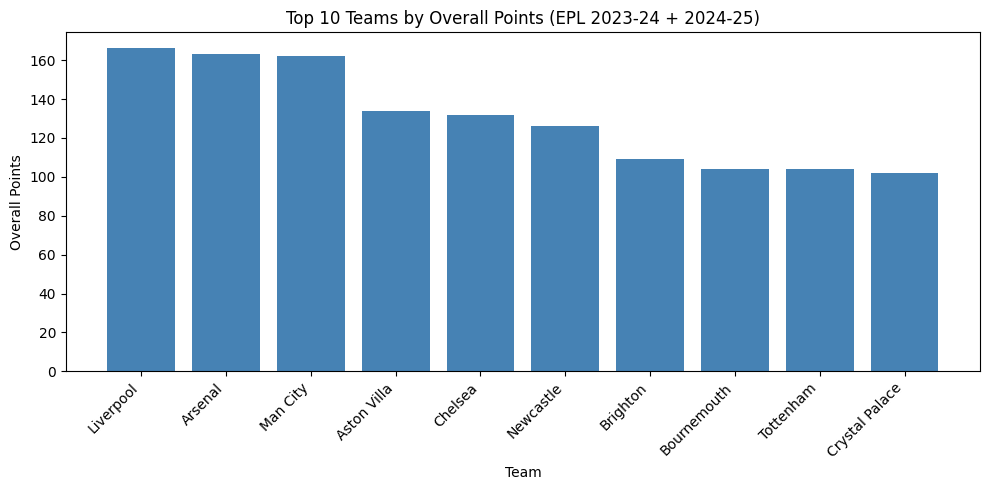

Liverpool leads by 3 points over Arsenal.


In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(top10["team"], top10["overall_points"], color="steelblue")
plt.title("Top 10 Teams by Overall Points (EPL 2023-24 + 2024-25)")
plt.xlabel("Team")
plt.ylabel("Overall Points")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

leader = top10.iloc[0]
runner_up = top10.iloc[1]
gap = leader["overall_points"] - runner_up["overall_points"]

print(f"{leader['team']} leads by {gap} points over {runner_up['team']}.")

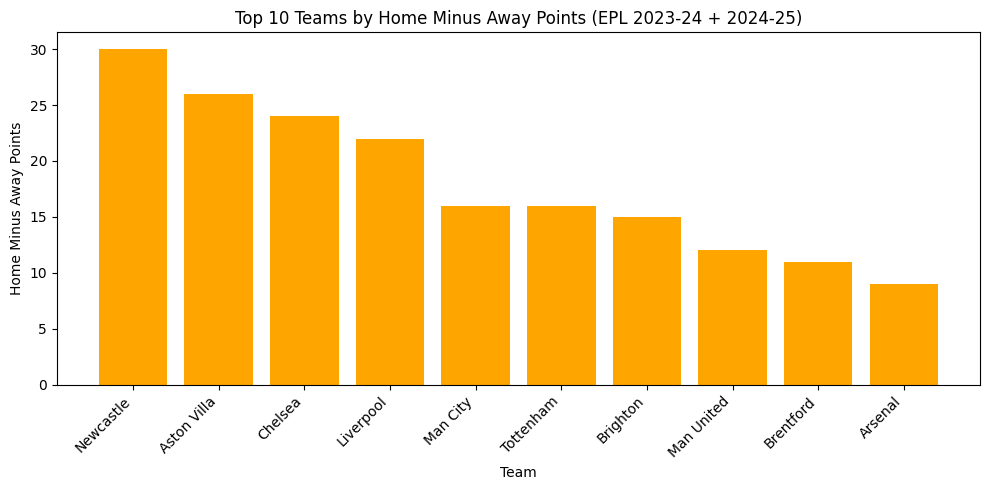

Newcastle has the biggest home advantage in EPL 2023-24 and 2024-25.


In [20]:

plt.figure(figsize=(10, 5))
plt.bar(hma_top10["team"], hma_top10["home_minus_away_points"], color="orange")
plt.title("Top 10 Teams by Home Minus Away Points (EPL 2023-24 + 2024-25)")
plt.xlabel("Team")
plt.ylabel("Home Minus Away Points")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

best_home = hma_top10.iloc[0]
print(f"{best_home['team']} has the biggest home advantage in EPL 2023-24 and 2024-25.")


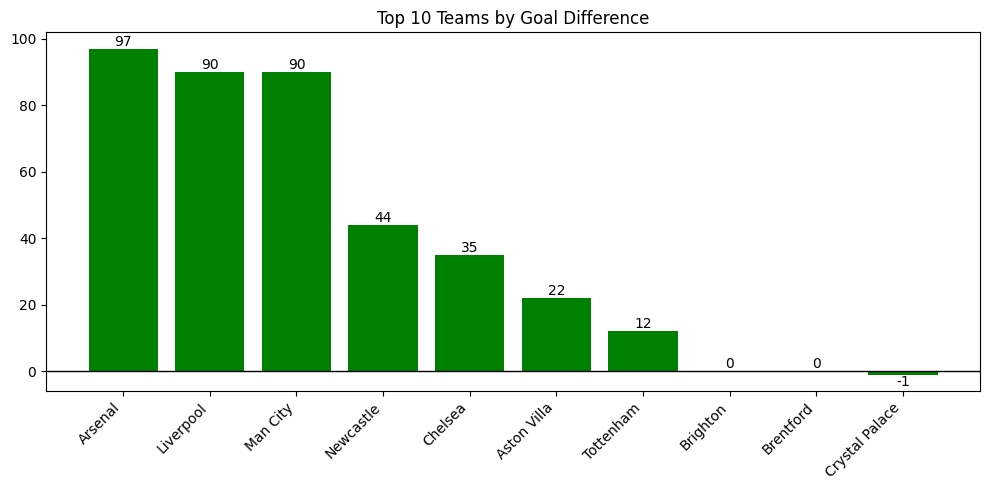

Arsenal has the highest goal difference of 97 in EPL 2023-2025 seasons.


In [21]:
plt.figure(figsize=(10,5))
plt.bar(gd_top10["team"], gd_top10["overall_goal_difference"], color="green")
plt.axhline(0, color="black", linewidth=1)  # zero line
plt.title("Top 10 Teams by Goal Difference")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
for i, v in enumerate(gd_top10["overall_goal_difference"]):
    plt.text(i, v, str(v), ha="center", va="bottom" if v >= 0 else "top")

plt.show()

gd_top_team = gd_top10.iloc[0]

print(f"{gd_top_team['team']} has the highest goal difference of {gd_top_team['overall_goal_difference']} in EPL 2023-2025 seasons.")

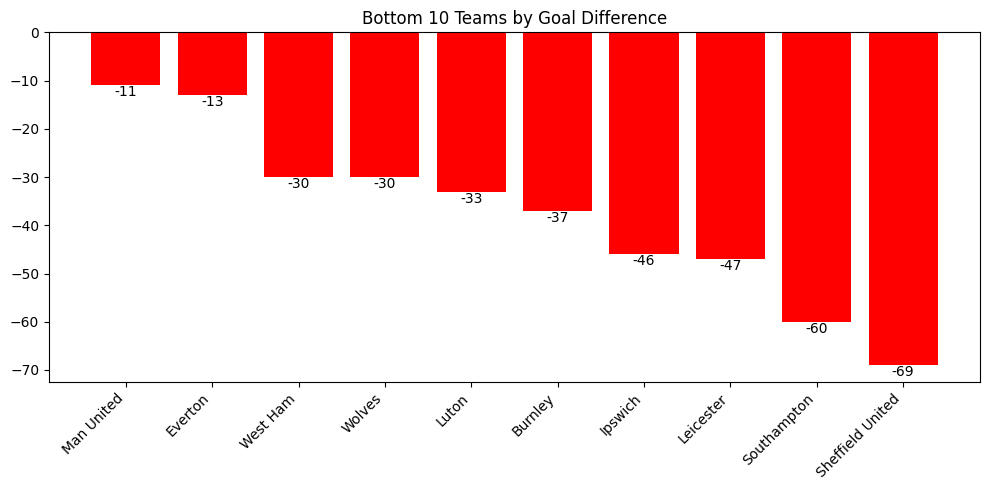

Sheffield United has the lowest goal difference of -69 in EPL 2023-2025 seasons.


In [22]:
plt.figure(figsize=(10,5))
plt.bar(gd_bottom10["team"], gd_bottom10["overall_goal_difference"], color="red")
plt.title("Bottom 10 Teams by Goal Difference")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
for i, v in enumerate(gd_bottom10["overall_goal_difference"]):
    plt.text(i, v, str(v), ha="center", va="bottom" if v >= 0 else "top")
plt.show()


gd_bottom_team = gd_bottom10.iloc[-1]  
print(f"{gd_bottom_team['team']} has the lowest goal difference of {gd_bottom_team['overall_goal_difference']} in EPL 2023-2025 seasons.")




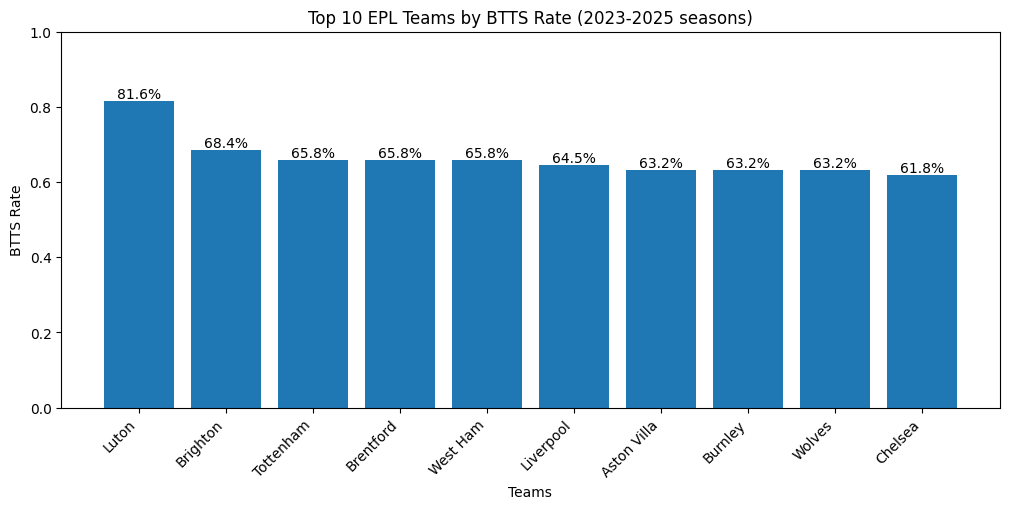

Luton has the highest BTTS rate of 81.6% among 23 teams


In [23]:
plt.figure(figsize=(10,5))
plt.bar(top10_btts_rate["team"], top10_btts_rate["btts_rate"])
plt.title("Top 10 EPL Teams by BTTS Rate (2023-2025 seasons)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.ylabel("BTTS Rate")
plt.xlabel("Teams")
plt.ylim(0, 1)
for i, v in enumerate(top10_btts_rate["btts_rate"]):
    plt.text(i, v, f"{v:.1%}", ha="center", va="bottom")
plt.show()

top_btts_team = top10_btts_rate.iloc[0]

print(f"{top_btts_team['team']} has the highest BTTS rate of {top_btts_team['btts_rate']:.1%} among {len(btts_rate)} teams")

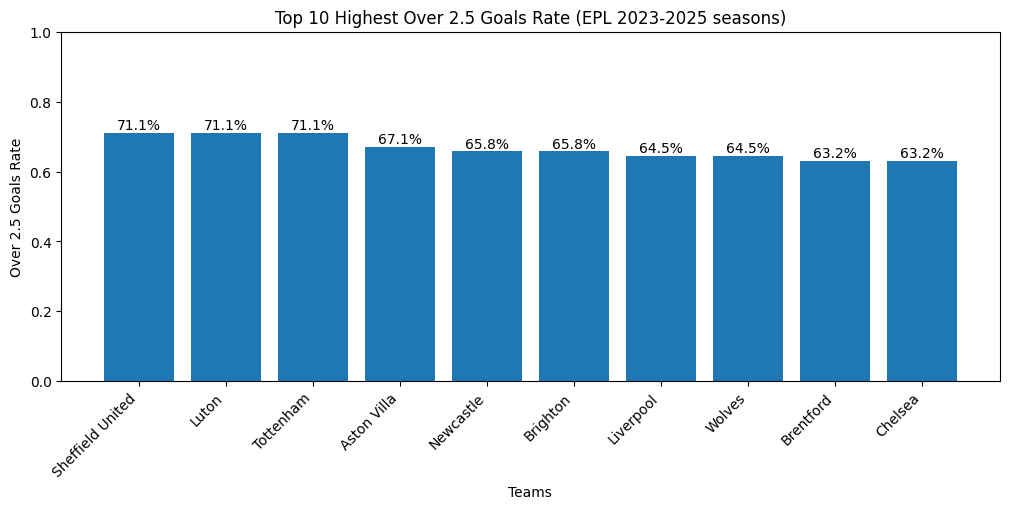

Sheffield United has the highest over 2.5 goals rate among 23 teams during 2023-2025 seasons


In [24]:
plt.figure(figsize=(10,5))
plt.bar(top10_over2_5["team"], top10_over2_5["over_2_5_rate"])
plt.title("Top 10 Highest Over 2.5 Goals Rate (EPL 2023-2025 seasons)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.xlabel("Teams")
plt.ylabel("Over 2.5 Goals Rate")
plt.ylim(0, 1)
for i,v in enumerate(top10_over2_5["over_2_5_rate"]):
    plt.text(i, v, f"{v:.1%}", ha="center", va="bottom")
plt.show()

top_over2_5_team = top10_over2_5.iloc[0]
print(f"{top_over2_5_team['team']} has the highest over 2.5 goals rate among {len(over2_5_rate)} teams during 2023-2025 seasons")

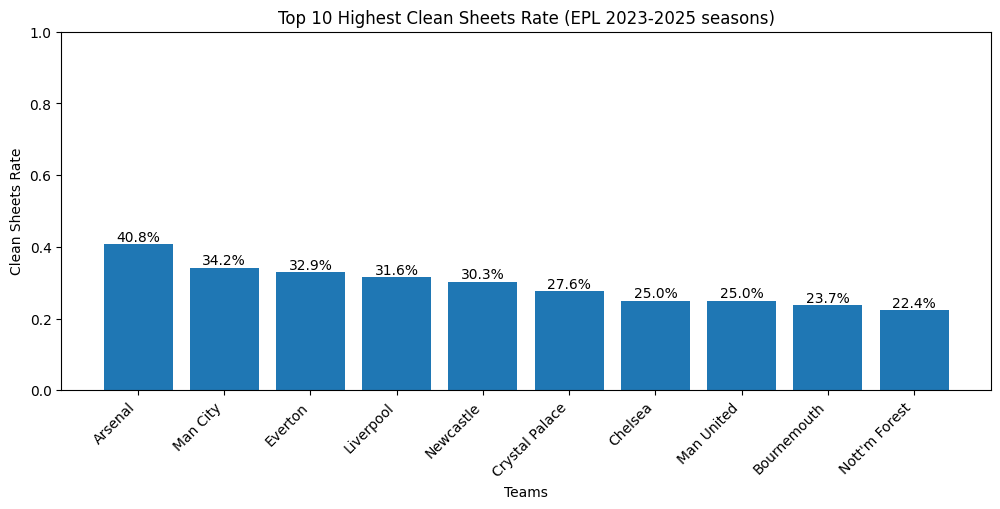

Arsenal has the highest clean sheets rate among 23 teams during 2023-2025 seasons


In [25]:
plt.figure(figsize=(10,5))
plt.bar(top10_cs["team"], top10_cs["clean_sheet_rate"])
plt.title("Top 10 Highest Clean Sheets Rate (EPL 2023-2025 seasons)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.xlabel("Teams")
plt.ylabel("Clean Sheets Rate")
plt.ylim(0, 1)
for i,v in enumerate(top10_cs["clean_sheet_rate"]):
    plt.text(i, v, f"{v:.1%}", ha="center", va="bottom")
plt.show()

top_cs_team = top10_cs.iloc[0]
print(f"{top_cs_team['team']} has the highest clean sheets rate among {len(clean_sheet_stats)} teams during 2023-2025 seasons")


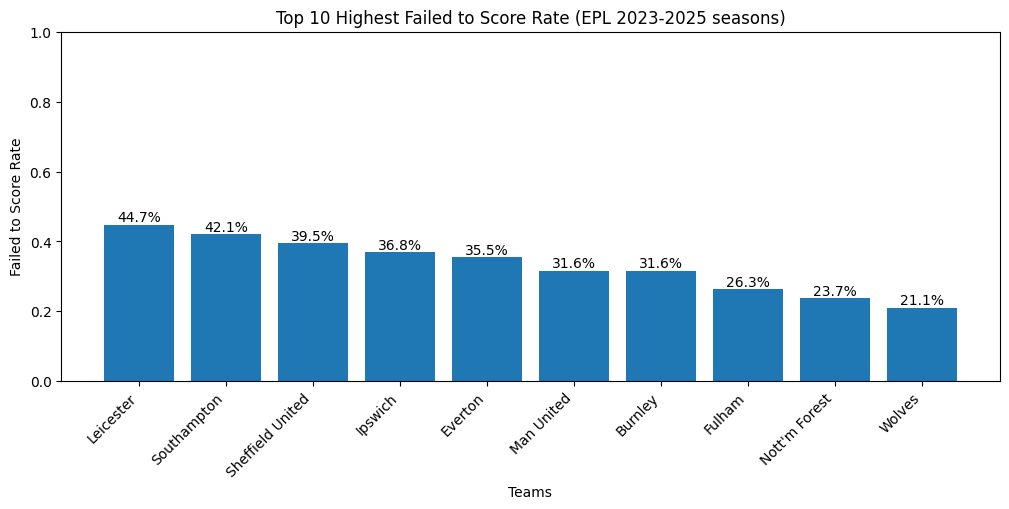

Leicester has the highest failed to score rate among 23 teams during 2023-2025 seasons


In [26]:
plt.figure(figsize=(10,5))
plt.bar(top10_fts["team"], top10_fts["failed_to_score_rate"])
plt.title("Top 10 Highest Failed to Score Rate (EPL 2023-2025 seasons)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.xlabel("Teams")
plt.ylabel("Failed to Score Rate")
plt.ylim(0, 1)
for i,v in enumerate(top10_fts["failed_to_score_rate"]):
    plt.text(i, v, f"{v:.1%}", ha="center", va="bottom")
plt.show()

top_fts_team = top10_fts.iloc[0]
print(f"{top_fts_team['team']} has the highest failed to score rate among {len(fts_stats)} teams during 2023-2025 seasons")

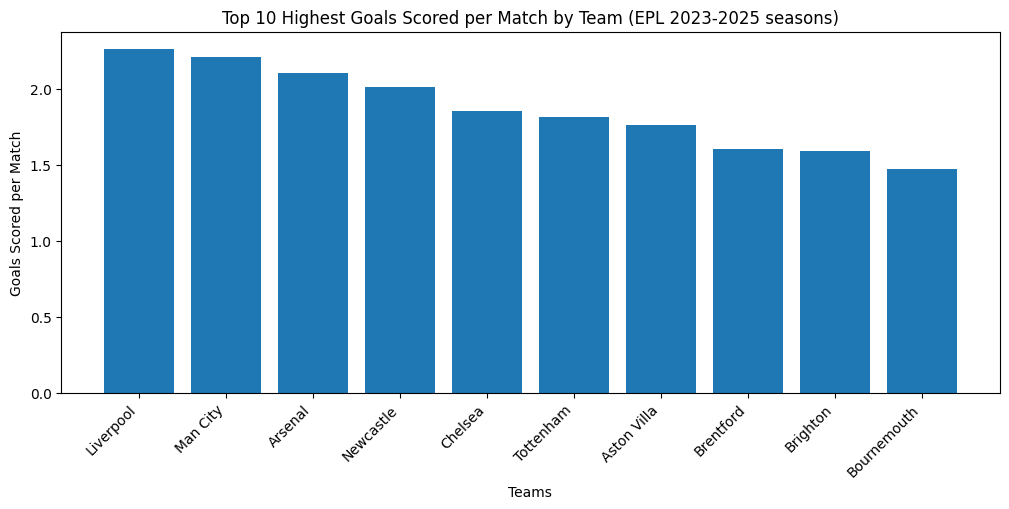

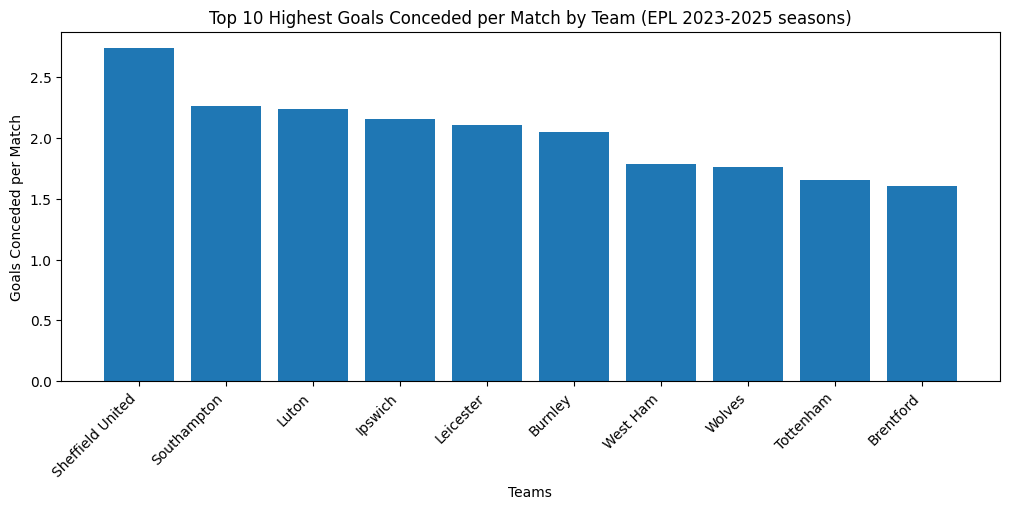

Liverpool has the highest goals scored per match among 23 teams during 2023-2025 seasons with 2.263157894736842
Sheffield United has the highest goals conceded per match among 23 teams during 2023-2025 seasons with 2.736842105263158


In [27]:
plt.figure(figsize=(10,5))
plt.bar(top10_gspm["team"], top10_gspm["goals_scored_per_match"])
plt.title("Top 10 Highest Goals Scored per Match by Team (EPL 2023-2025 seasons)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.xlabel("Teams")
plt.ylabel("Goals Scored per Match")
plt.show()

plt.figure(figsize=(10,5))
plt.bar(top10_gcpm["team"], top10_gcpm["goals_conceded_per_match"])
plt.title("Top 10 Highest Goals Conceded per Match by Team (EPL 2023-2025 seasons)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.xlabel("Teams")
plt.ylabel("Goals Conceded per Match")
plt.show()

top_gspm_team = top10_gspm.iloc[0]
top_gcpm_team = top10_gcpm.iloc[0]
print(f"{top_gspm_team['team']} has the highest goals scored per match among {len(gpm_stats)} teams during 2023-2025 seasons with {top_gspm_team['goals_scored_per_match']}")
print(f"{top_gcpm_team['team']} has the highest goals conceded per match among {len(gpm_stats)} teams during 2023-2025 seasons with {top_gcpm_team['goals_conceded_per_match']}")

## Final Insights (Answers to Project Questions)

This section answers the declared starter-project questions using computed metrics.


In [28]:
import numpy as np

# Q1: best home record
q1 = home_summary.sort_values("home_points", ascending=False).iloc[0]

# Q2: worst away record
q2 = away_summary.sort_values("away_points", ascending=True).iloc[0]

# Q3: highest goals scored per match
q3 = overall_summary.sort_values("goals_scored_per_match", ascending=False).iloc[0]

# Q4: highest goals conceded per match
q4 = overall_summary.sort_values("goals_conceded_per_match", ascending=False).iloc[0]

# Q5: highest clean sheet rate
q5 = clean_sheet_stats.sort_values("clean_sheet_rate", ascending=False).iloc[0]

# Q6: highest failed-to-score rate
q6 = fts_stats.sort_values("failed_to_score_rate", ascending=False).iloc[0]

# Q7: highest BTTS rate
q7 = overall_summary.sort_values("btts_rate", ascending=False).iloc[0]

# Q8: highest over 2.5 rate
q8 = over2_5_rate.sort_values("over_2_5_rate", ascending=False).iloc[0]

# Q9: recent form (last 5 matches)
home_log = matches_features[["match_date", "home_team", "home_goals", "away_goals", "home_points", "home_win_flag", "draw_flag"]].copy()
home_log["team"] = home_log["home_team"]
home_log["points"] = home_log["home_points"]
home_log["result"] = home_log["full_result"] if "full_result" in home_log.columns else ""
home_log["result"] = np.select([home_log["home_win_flag"] == 1, home_log["draw_flag"] == 1], ["W", "D"], default="L")

away_log = matches_features[["match_date", "away_team", "away_points", "away_win_flag", "draw_flag"]].copy()
away_log["team"] = away_log["away_team"]
away_log["points"] = away_log["away_points"]
away_log["result"] = np.select([away_log["away_win_flag"] == 1, away_log["draw_flag"] == 1], ["W", "D"], default="L")

recent_form = pd.concat([
    home_log[["match_date", "team", "points", "result"]],
    away_log[["match_date", "team", "points", "result"]]
], ignore_index=True).sort_values(["team", "match_date"])

last5 = recent_form.groupby("team", group_keys=False).tail(5)
recent_summary = last5.groupby("team").agg(last5_points=("points", "sum"))
recent_summary["form"] = last5.groupby("team")["result"].apply(lambda x: "".join(x.tolist()))
q9_best = recent_summary.sort_values("last5_points", ascending=False).iloc[0]
q9_worst = recent_summary.sort_values("last5_points", ascending=True).iloc[0]

# Q10: stronger at home than away
q10 = overall_summary.sort_values("home_minus_away_points", ascending=False).iloc[0]

print("Q1. Best home record:")
print(f"- {q1['team']} with {q1['home_points']:.0f} home points.")

print("\nQ2. Worst away record:")
print(f"- {q2['team']} with {q2['away_points']:.0f} away points.")

print("\nQ3. Most goals scored per match:")
print(f"- {q3['team']} at {q3['goals_scored_per_match']:.2f} goals per match.")

print("\nQ4. Most goals conceded per match:")
print(f"- {q4['team']} at {q4['goals_conceded_per_match']:.2f} goals conceded per match.")

print("\nQ5. Highest clean sheet rate:")
print(f"- {q5['team']} at {q5['clean_sheet_rate']:.1%}.")

print("\nQ6. Highest failed-to-score rate:")
print(f"- {q6['team']} at {q6['failed_to_score_rate']:.1%}.")

print("\nQ7. Highest BTTS rate:")
print(f"- {q7['team']} at {q7['btts_rate']:.1%}.")

print("\nQ8. Highest over 2.5 rate:")
print(f"- {q8['team']} at {q8['over_2_5_rate']:.1%}.")

print("\nQ9. Recent form (last 5 matches):")
print(f"- Best: {q9_best.name} with {q9_best['last5_points']:.0f} points, form {q9_best['form']}.")
print(f"- Weakest: {q9_worst.name} with {q9_worst['last5_points']:.0f} points, form {q9_worst['form']}.")

print("\nQ10. Strongest home-vs-away advantage:")
print(f"- {q10['team']} with a {q10['home_minus_away_points']:.0f}-point home-away gap.")


Q1. Best home record:
- Liverpool with 94 home points.

Q2. Worst away record:
- Sheffield United with 6 away points.

Q3. Most goals scored per match:
- Liverpool at 2.26 goals per match.

Q4. Most goals conceded per match:
- Sheffield United at 2.74 goals conceded per match.

Q5. Highest clean sheet rate:
- Arsenal at 40.8%.

Q6. Highest failed-to-score rate:
- Leicester at 44.7%.

Q7. Highest BTTS rate:
- Luton at 81.6%.

Q8. Highest over 2.5 rate:
- Sheffield United at 71.1%.

Q9. Recent form (last 5 matches):
- Best: Brighton with 13 points, form WDWWW.
- Weakest: Sheffield United with 0 points, form LLLLL.

Q10. Strongest home-vs-away advantage:
- Newcastle with a 30-point home-away gap.
